# Battery Current Time Series Model Evaluation

## Import Library

In [1]:
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from TimeSeries.src.preprocessing.preprocessing import get_datasets

2026-03-05 14:01:42.380140: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 14:01:42.458535: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 14:01:44.467459: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load Test Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = get_datasets()

Loading:  /home/abel-putra/AndroidMonitoring/Clustering/data/dataset/dataset.csv
Data Shape:  (3423, 11)
Param Saved
Feature Scaled
Feature Shape:  (3363, 45, 7)
Label Shape:  (3363, 15)
Train Shape:  (2017, 45, 7)
Validation Shape:  (673, 45, 7)
Test Shape:  (673, 45, 7)


In [3]:
param_dir = "../data/param/params.json"
with open(param_dir) as f:
    params = json.load(f)

mean_feature = params["mean_feature"]
scale_feature = params["scale_feature"]
mean_target = params["mean_target"]
scale_target = params["scale_target"]
print("Mean Feature: ", mean_feature)
print("Scale Feature: ", scale_feature)
print("Mean Target: ", mean_target)
print("Scale Target: ", scale_target)

Mean Feature:  [49.287759275489336, 74.57201285422144, 47.04995617879054, 5.0568425394316385, 81.5293001301909, 0.9693251533742331, 25.79959100204499]
Scale Feature:  [15.78064614053583, 3.648842509588785, 17.312143985870268, 10.512427678025546, 220.48422022646653, 0.17243520641172017, 3.487154317132191]
Mean Target:  [-332.4049079754601]
Scale Target:  [174.77256937852377]


## Load Model

In [4]:
model_rnn = tf.keras.models.load_model('../data/model/RNN.keras')
model_lstm = tf.keras.models.load_model('../data/model/LSTM.keras')
model_gru = tf.keras.models.load_model('../data/model/GRU.keras')
model_cnn_rnn = tf.keras.models.load_model('../data/model/CNN_RNN.keras')
model_cnn_lstm = tf.keras.models.load_model('../data/model/CNN_LSTM.keras')
model_cnn_gru = tf.keras.models.load_model('../data/model/CNN_GRU.keras')

E0000 00:00:1772694105.280553   36597 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772694105.294258   36597 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Evaluation

In [5]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)
pred_cnn_rnn = model_cnn_rnn.predict(X_test)
pred_cnn_lstm = model_cnn_lstm.predict(X_test)
pred_cnn_gru = model_cnn_gru.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [6]:
mae_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_rnn.reshape(-1)
)
mae_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_lstm.reshape(-1)
)
mae_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_gru.reshape(-1)
)
mae_cnn_rnn = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_rnn.reshape(-1)
)
mae_cnn_lstm = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_lstm.reshape(-1)
)
mae_cnn_gru = mean_absolute_error(
    y_test.reshape(-1),
    pred_cnn_gru.reshape(-1)
)

print("MAE RNN:", mae_rnn)
print("MAE LSTM:", mae_lstm)
print("MAE GRU:", mae_gru)
print("MAE RNN (CNN):", mae_cnn_rnn)
print("MAE LSTM (CNN):", mae_cnn_rnn)
print("MAE GRU (CNN):", mae_cnn_rnn)

MAE RNN: 0.7168109717061768
MAE LSTM: 0.6607205784414147
MAE GRU: 0.632261103466806
MAE RNN (CNN): 0.6774442446528165
MAE LSTM (CNN): 0.6774442446528165
MAE GRU (CNN): 0.6774442446528165


In [7]:
pred_rnn_real = pred_rnn * scale_target[0] + mean_target[0]
pred_lstm_real = pred_lstm * scale_target[0] + mean_target[0]
pred_gru_real = pred_gru * scale_target[0] + mean_target[0]
pred_cnn_rnn_real = pred_cnn_rnn * scale_target[0] + mean_target[0]
pred_cnn_lstm_real = pred_cnn_lstm * scale_target[0] + mean_target[0]
pred_cnn_gru_real = pred_cnn_gru * scale_target[0] + mean_target[0]

y_test_real = y_test * scale_target[0] + mean_target[0]

In [8]:
idx = np.random.randint(0, len(y_test_real))
avg_drain = np.mean(y_test_real)

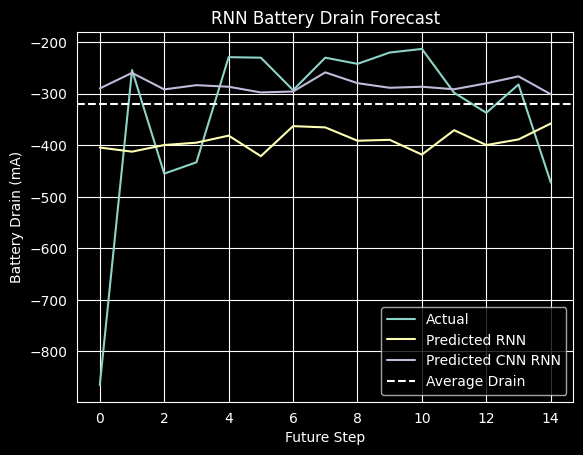

In [9]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_rnn_real[idx], label="Predicted RNN")
plt.plot(pred_cnn_rnn_real[idx], label="Predicted CNN RNN")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.title("RNN Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

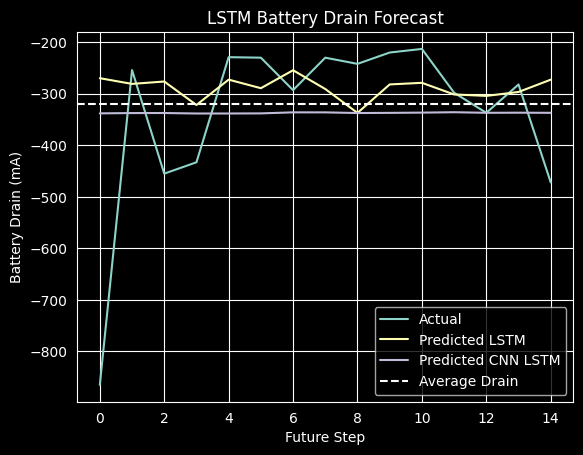

In [10]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_lstm_real[idx], label="Predicted LSTM")
plt.plot(pred_cnn_lstm_real[idx], label="Predicted CNN LSTM")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.title("LSTM Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

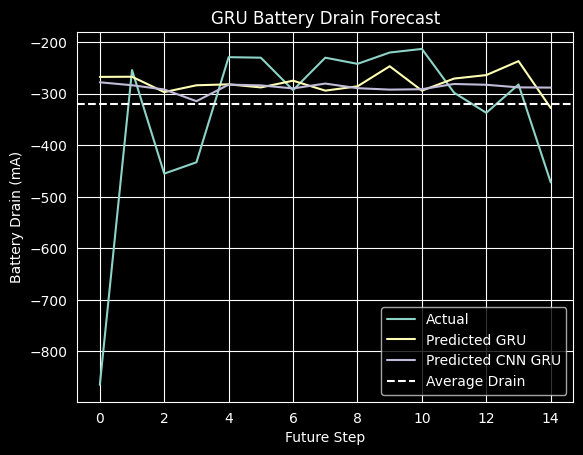

In [11]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_gru_real[idx], label="Predicted GRU")
plt.plot(pred_cnn_gru_real[idx], label="Predicted CNN GRU")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.title("GRU Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()

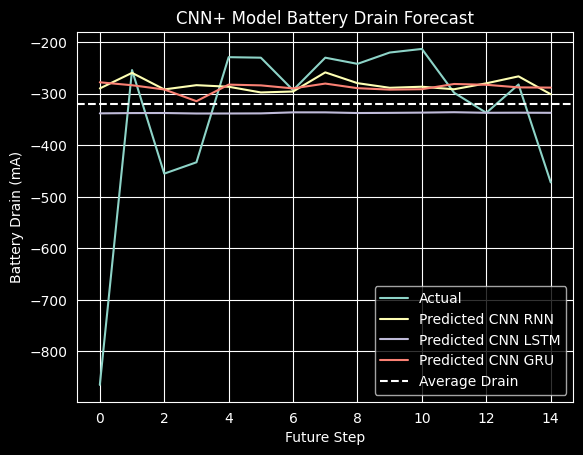

In [12]:
plt.figure()
plt.plot(y_test_real[idx], label="Actual")
plt.plot(pred_cnn_rnn_real[idx], label="Predicted CNN RNN")
plt.plot(pred_cnn_lstm_real[idx], label="Predicted CNN LSTM")
plt.plot(pred_cnn_gru_real[idx], label="Predicted CNN GRU")
plt.axhline(avg_drain, linestyle='--', label="Average Drain")
plt.title("CNN+ Model Battery Drain Forecast")
plt.xlabel("Future Step")
plt.ylabel("Battery Drain (mA)")
plt.legend()
plt.show()